In [18]:
%load_ext autoreload
%autoreload 2

import os 
import sys
from pathlib import Path

# 1. Setup Configuration
repo_root = Path(".").resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

config_path = repo_root / ".dcbench" / "dcbench-config.yaml"
os.makedirs(repo_root / ".dcbench", exist_ok=True)

local_dir = repo_root / ".dcbench"

config_content = f"""local_dir: {local_dir}
public_bucket_name: dcbench
hidden_bucket_name: dcbench-hidden
celeba_dir: {local_dir / 'datasets' / 'celeba'}
imagenet_dir: {local_dir / 'datasets' / 'imagenet'}
"""

with open(config_path, "w") as f:
    f.write(config_content)

os.environ["DCBENCH_CONFIG"] = str(config_path)

# 2. Add Domino to Path
# The path is relative to the dcbench root (../../sdbench/postprocessors)
domino_path = (repo_root.parent.parent / "sdbench" / "postprocessors").resolve()
if str(domino_path) not in sys.path:
    sys.path.insert(0, str(domino_path))

import dcbench
import meerkat as mk
from domino import DominoSlicer
from dcbench.tasks.slice_discovery.run import run_sdms

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# `dcbench`: Slice Discovery Demo

This notebook showcases the interface for Slice Discovery in `dcbench`. You can read more about the task in our [documentation](https://dcbench.readthedocs.io/en/latest/tasks.html#slice-discovery) and on our [website](https://www.datacentricai.cc/benchmark/).

In [19]:
dcbench.tasks

,name,summary
minidata,Minimal Data Selection,"Given a large training dataset, what is the sm..."
slice_discovery,Slice Discovery,Machine learnings models that achieve high ove...
budgetclean,Data Cleaning on a Budget,"When it comes to data preparation, data cleani..."


## Exploring problems

In this notebook, we'll focus on the [Slice Discovery](https://dcbench.readthedocs.io/en/latest/tasks.html#slice-discovery) task. 

In the `dcbench` API, each task is represented by a `dcbench.Task` object that can be accessed by *task_id* (*e.g.* `dcbench.tasks["slice_discovery"]`).

In [20]:
task = dcbench.tasks["slice_discovery"]
task.problems

,alpha,dataset,n_pred_slices,slice_category,slice_names,target_name
p_72776,0.2000,celeba,5,correlation,"[wearing_lipstick=0_young=1, wearing_lipstick=...",wearing_lipstick
p_72793,0.6000,celeba,5,correlation,"[wearing_necklace=0_black_hair=1, wearing_neck...",wearing_necklace
p_72800,0.2000,celeba,5,correlation,"[wearing_necklace=0_brown_hair=1, wearing_neck...",wearing_necklace
p_72799,0.6000,celeba,5,correlation,"[wearing_necklace=0_smiling=1, wearing_necklac...",wearing_necklace
p_72802,0.2000,celeba,5,correlation,"[wearing_necklace=0_wearing_lipstick=1, wearin...",wearing_necklace
...,...,...,...,...,...,...
p_122649,0.2000,imagenet,5,noisy_label,[watch.n.01],timepiece.n.01
p_117333,0.0500,imagenet,5,rare,[cart.n.01],vehicle.n.01
p_118951,0.0500,imagenet,5,rare,[punch.n.02],food.n.01
p_120032,0.0500,imagenet,5,rare,[mushroom.n.05],vegetable.n.01


Let's select a problem that uses the ImageNet dataset.

In [21]:
problems = [p for p in task.problems.values() if p.attributes["dataset"] == "imagenet"]
problem = problems[0]
problem

SliceDiscoveryProblem(artifacts={'activations': 'DataPanelArtifact', 'base_dataset': 'VisionDatasetArtifact', 'clip': 'DataPanelArtifact', 'model': 'ModelArtifact', 'test_predictions': 'DataPanelArtifact', 'test_slices': 'DataPanelArtifact', 'val_predictions': 'DataPanelArtifact'}, attributes={'alpha': 0.30000000000000004, 'dataset': 'imagenet', 'n_pred_slices': 5, 'slice_category': 'noisy_label', 'slice_names': ['cougar.n.01'], 'target_name': 'cat.n.01'})

## Running Slice Discovery with Domino

We can use the `run_sdms` function to run a slicer (like `DominoSlicer`) on a list of problems.

In [22]:
# Run Domino on the selected problem
solutions, metrics = run_sdms(
     [problem],
    slicer_class=DominoSlicer,
    slicer_config=dict(
        y_hat_log_likelihood_weight=10,
        y_log_likelihood_weight=10,
    ),
    encoder="clip",
    num_workers=10 # Set to > 0 for parallel execution with Ray
)

  0%|          | 0/1 [00:00<?, ?it/s]

(_run_sdms pid=246122) /home/azureuser/.local/lib/python3.10/site-packages/meerkat/ml/__init__.py:7: ExperimentalWarning: The `meerkat.ml` module is experimental and has limited test coverage. Proceed with caution.
(_run_sdms pid=246122)   warnings.warn(
 22%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [23]:
metrics

,target_slice_idx,target_slice_name,pred_slice_idx,average_precision,precision-at-10,precision-at-25,precision,recall,f1_score,support,solution_id,problem_id
0,0,cougar.n.01,2,0.147043,0.4,0.32,0.106828,0.737643,0.186628,None,3e61b76367bb481bb9ccdc9626a7e143,p_122446


In [34]:
(-dp["slice_preds"][:, 4]).argsort()

array([   0, 4767, 4766, ..., 2671, 2648, 6003])

## Visualizing Results

We can visualize the top slices discovered by Domino by merging the solution with the base dataset.

,id (PandasSeriesColumn),slice_preds (NumpyArrayColumn),slice_probs (NumpyArrayColumn),image (ImageColumn),name (PandasSeriesColumn),synset (PandasSeriesColumn)
0,n04273569_10997,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",,speedboat,n04273569
1,n01930112_3445,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",,"nematode, nematode worm, roundworm",n01930112
2,n02607072_12341,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",,anemone fish,n02607072
3,n04086273_9923,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",,"revolver, six-gun, six-shooter",n04086273
4,n01770081_6985,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",,"harvestman, daddy longlegs, Phalangium opilio",n01770081
5,n04041544_15983,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",,"radio, wireless",n04041544
6,n04154565_7338,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",,screwdriver,n04154565
7,n03764736_5449,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",,milk can,n03764736
8,n02037110_1683,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",,"oystercatcher, oyster catcher",n02037110
9,n04049303_10008,"np.ndarray(shape=(5,))","np.ndarray(shape=(5,))",,rain barrel,n04049303

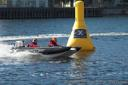
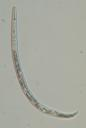
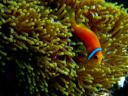
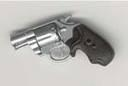
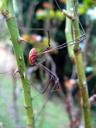
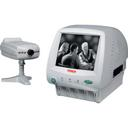
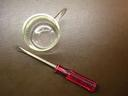
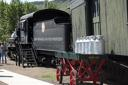
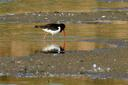
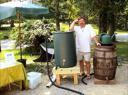

In [32]:
solution = solutions[0]
dataset = problem.artifacts["base_dataset"].load()

# Merge predictions with the dataset
dp = mk.merge(solution["pred_slices"], dataset, on="id")

top_examples = dp.lz[(-dp["slice_preds"][:, 4]).argsort()[:10]]
top_examples

You can use Meerkat's interactive components to explore the slices more effectively if you are running this in an environment that supports them.